# Análise exploratória

In [33]:
#importando dataset
import pandas as pd

dataset = pd.read_csv(r"Titanic-Dataset.csv")
dataset.shape

(891, 12)

In [34]:
#Fazendo a leitura
dataset.head(40)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,NaN,S
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,NaN,S
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,NaN,C


In [35]:
dataset.dtypes

PassengerId      int64
Survived         int64
Pclass           int64
Name               str
Sex                str
Age            float64
SibSp            int64
Parch            int64
Ticket             str
Fare           float64
Cabin              str
Embarked           str
dtype: object

In [36]:
#Verificação de valores nulos
dataset.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [37]:
#Verificação estatística
dataset.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


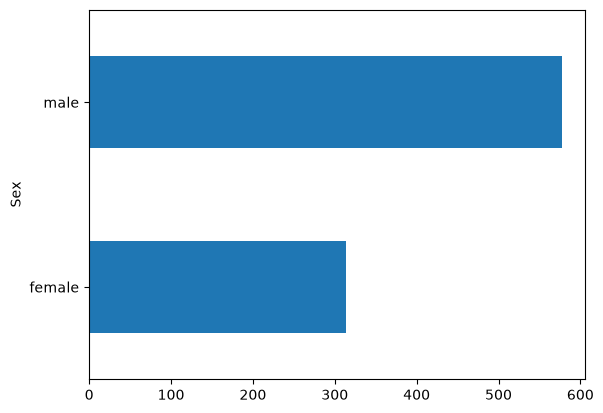

In [38]:
#Verificando as informações da coluna de Sexo
dataset.groupby('Sex')['Sex'].count().plot.barh();

In [39]:
#Verificando se existem valores duplicados
dataset.duplicated().sum()

np.int64(0)

In [40]:
#Entendendo padrões das colunas

#print(dataset['Ticket'].unique())
#print(dataset['Cabin'].unique())
#print(dataset['Fare'].unique())
print(dataset['Age'].unique())

[22.   38.   26.   35.     nan 54.    2.   27.   14.    4.   58.   20.
 39.   55.   31.   34.   15.   28.    8.   19.   40.   66.   42.   21.
 18.    3.    7.   49.   29.   65.   28.5   5.   11.   45.   17.   32.
 16.   25.    0.83 30.   33.   23.   24.   46.   59.   71.   37.   47.
 14.5  70.5  32.5  12.    9.   36.5  51.   55.5  40.5  44.    1.   61.
 56.   50.   36.   45.5  20.5  62.   41.   52.   63.   23.5   0.92 43.
 60.   10.   64.   13.   48.    0.75 53.   57.   80.   70.   24.5   6.
  0.67 30.5   0.42 34.5  74.  ]


In [41]:
#Verificando valor de mediana da coluna de idade

print("Mediana:", dataset['Age'].median())

Mediana: 28.0


In [42]:
#Removendo colunas consideradas irrelevantes para a análise
dataset = dataset.drop(columns=['Cabin'])
dataset = dataset.drop(columns=['PassengerId'])
dataset = dataset.drop(columns=['Ticket'])
dataset = dataset.drop(columns=['Name'])
dataset = dataset.drop(columns=['SibSp'])


In [43]:
#Preenchendo valores nulos da coluna de idade com a mediana

dataset['Age'] = dataset['Age'].fillna(dataset['Age'].median())


In [44]:
#Arredondando idades para números inteiros
dataset['Age'] = dataset['Age'].round(0).astype(int)

In [45]:
#Conferindo novamente os valores nulos
dataset.isnull().sum()

Survived    0
Pclass      0
Sex         0
Age         0
Parch       0
Fare        0
Embarked    2
dtype: int64

In [46]:
#Preenchendo valores nulos de Embarked com o valor da moda
dataset['Embarked'] = dataset['Embarked'].fillna(dataset['Embarked'].mode()[0])


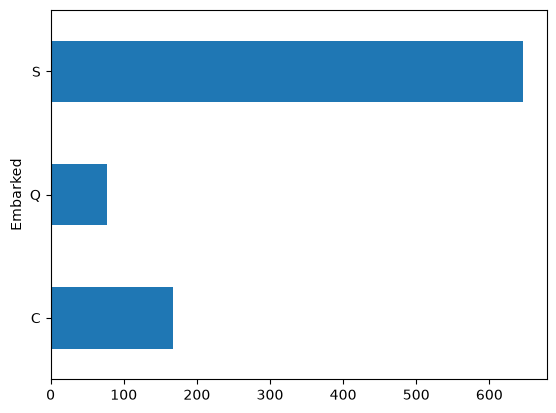

In [47]:
#Verificando a distribuição dos valores da coluna Embarked
dataset.groupby('Embarked')['Embarked'].count().plot.barh();

In [48]:
#Verificando o valor mínimo da coluna Fare
print(f"Valor mínimo de Fare: {dataset['Fare'].min()}")

Valor mínimo de Fare: 0.0


In [49]:
#Verificando passageiros com tarifa zero
zero_fares = dataset[dataset['Fare'] == 0]
print(f"\nPassageiros com tarifa zero:\n{len(zero_fares)}\n")


Passageiros com tarifa zero:
15



In [50]:
#Condição para exibir os passageiros com tarifa zero, caso existam
if len(zero_fares) > 0:
    print(zero_fares[['Survived', 'Pclass', 'Sex', 'Age','Parch', 'Fare']]) 
else:
    print("Nenhum passageiro com tarifa zero encontrado no dataset.")

     Survived  Pclass   Sex  Age  Parch  Fare
179         0       3  male   36      0   0.0
263         0       1  male   40      0   0.0
271         1       3  male   25      0   0.0
277         0       2  male   28      0   0.0
302         0       3  male   19      0   0.0
413         0       2  male   28      0   0.0
466         0       2  male   28      0   0.0
481         0       2  male   28      0   0.0
597         0       3  male   49      0   0.0
633         0       1  male   28      0   0.0
674         0       2  male   28      0   0.0
732         0       2  male   28      0   0.0
806         0       1  male   39      0   0.0
815         0       1  male   28      0   0.0
822         0       1  male   38      0   0.0


In [51]:
#Removendo passageiros com tarifa zero do dataset
dataset = dataset[dataset['Fare'] != 0.0]


In [52]:
#Verificando passageiros com tarifa zero após a correção
zero_fares = dataset[dataset['Fare'] == 0]
print(f"\nPassageiros com tarifa zero:\n{len(zero_fares)}\n")


Passageiros com tarifa zero:
0



In [53]:
#Verificando a distribuição da coluna Survived
dataset['Survived'].value_counts()

Survived
0    535
1    341
Name: count, dtype: int64

In [54]:
dataset

,Survived,Pclass,Sex,Age,Parch,Fare,Embarked
0,0,3,male,22,0,7.2500,S
1,1,1,female,38,0,71.2833,C
2,1,3,female,26,0,7.9250,S
3,1,1,female,35,0,53.1000,S
4,0,3,male,35,0,8.0500,S
...,...,...,...,...,...,...,...
886,0,2,male,27,0,13.0000,S
887,1,1,female,19,0,30.0000,S
888,0,3,female,28,2,23.4500,S
889,1,1,male,26,0,30.0000,C


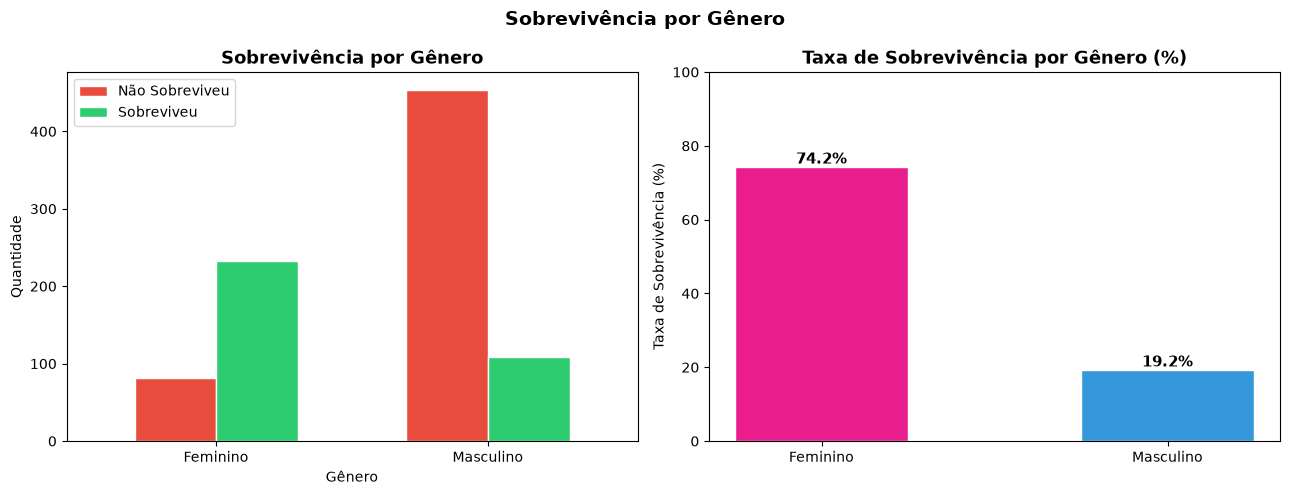

In [55]:
#Visualizando sobreviventes por gênero
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

#Quantidade total por gênero
contagem_sexo = dataset.groupby('Sex')['Survived'].value_counts().unstack()
contagem_sexo.plot(kind='bar', ax=axes[0], color=['#e74c3c', '#2ecc71'],
                   edgecolor='white', width=0.6)
axes[0].set_title('Sobrevivência por Gênero', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Gênero')
axes[0].set_ylabel('Quantidade')
axes[0].set_xticklabels(['Feminino', 'Masculino'], rotation=0)
axes[0].legend(['Não Sobreviveu', 'Sobreviveu'])

#Taxa de sobrevivência por gênero (%)
taxa_sexo = dataset.groupby('Sex')['Survived'].mean() * 100
axes[1].bar(['Feminino', 'Masculino'], taxa_sexo.values,
            color=['#e91e8c', '#3498db'], edgecolor='white', width=0.5)
for i, v in enumerate(taxa_sexo.values):
    axes[1].text(i, v + 1, f'{v:.1f}%', ha='center', fontweight='bold', fontsize=11)
axes[1].set_title('Taxa de Sobrevivência por Gênero (%)', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Taxa de Sobrevivência (%)')
axes[1].set_ylim(0, 100)

plt.suptitle('Sobrevivência por Gênero', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

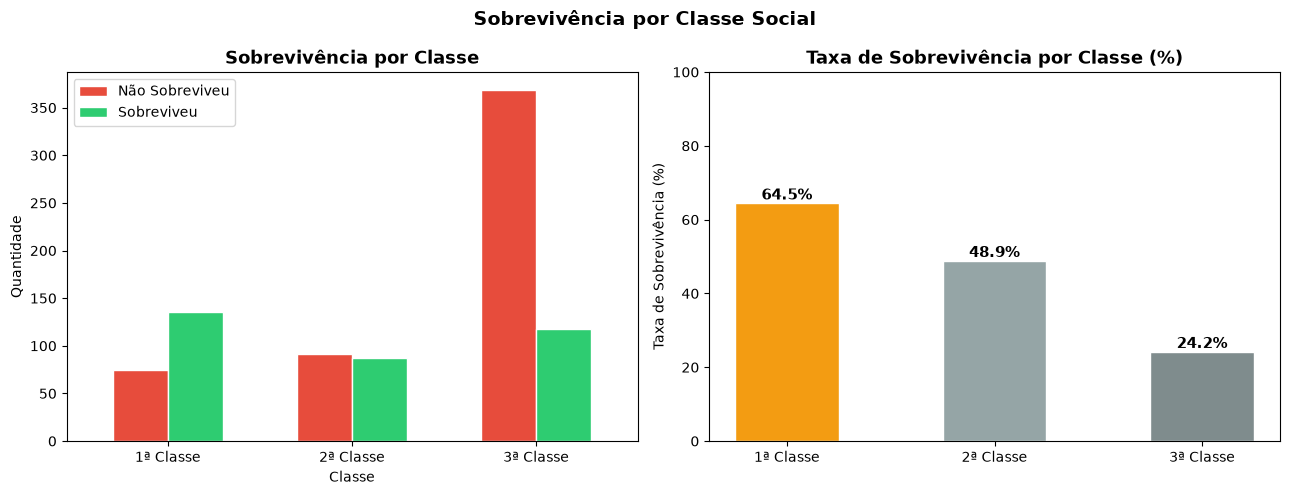

In [56]:
#Taxa de sobrevivência por classe social
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

#Quantidade por classe
contagem_classe = dataset.groupby('Pclass')['Survived'].value_counts().unstack()
contagem_classe.plot(kind='bar', ax=axes[0], color=['#e74c3c', '#2ecc71'],
                     edgecolor='white', width=0.6)
axes[0].set_title('Sobrevivência por Classe', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Classe')
axes[0].set_ylabel('Quantidade')
axes[0].set_xticklabels(['1ª Classe', '2ª Classe', '3ª Classe'], rotation=0)
axes[0].legend(['Não Sobreviveu', 'Sobreviveu'])

#Taxa de sobrevivência por classe
taxa_classe = dataset.groupby('Pclass')['Survived'].mean() * 100
axes[1].bar(['1ª Classe', '2ª Classe', '3ª Classe'], taxa_classe.values,
            color=['#f39c12', '#95a5a6', '#7f8c8d'], edgecolor='white', width=0.5)
for i, v in enumerate(taxa_classe.values):
    axes[1].text(i, v + 1, f'{v:.1f}%', ha='center', fontweight='bold', fontsize=11)
axes[1].set_title('Taxa de Sobrevivência por Classe (%)', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Taxa de Sobrevivência (%)')
axes[1].set_ylim(0, 100)

plt.suptitle('Sobrevivência por Classe Social', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

C:\Users\sarah\AppData\Local\Temp\ipykernel_7436\1674197614.py:23: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  axes[1].set_xticklabels(['1ª Classe', '2ª Classe', '3ª Classe'])


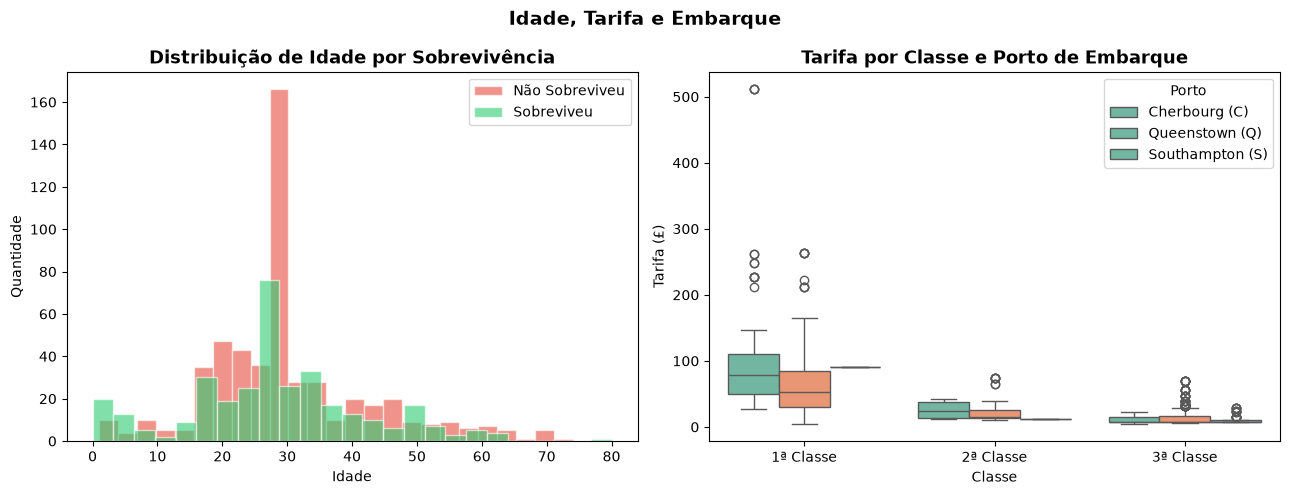

In [57]:
#Distribuição de idade e tarifa por sobrevivência e embarque
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

#Idade por sobrevivência
sobreviveu = dataset[dataset['Survived'] == 1]['Age']
nao_sobreviveu = dataset[dataset['Survived'] == 0]['Age']

axes[0].hist(nao_sobreviveu, bins=25, alpha=0.6, color='#e74c3c',
             label='Não Sobreviveu', edgecolor='white')
axes[0].hist(sobreviveu, bins=25, alpha=0.6, color='#2ecc71',
             label='Sobreviveu', edgecolor='white')
axes[0].set_title('Distribuição de Idade por Sobrevivência', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Idade')
axes[0].set_ylabel('Quantidade')
axes[0].legend()

#Tarifa por classe e embarque
sns.boxplot(data=dataset, x='Pclass', y='Fare', hue='Embarked',
            palette='Set2', ax=axes[1])
axes[1].set_title('Tarifa por Classe e Porto de Embarque', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Classe')
axes[1].set_ylabel('Tarifa (£)')
axes[1].set_xticklabels(['1ª Classe', '2ª Classe', '3ª Classe'])
axes[1].legend(title='Porto', labels=['Cherbourg (C)', 'Queenstown (Q)', 'Southampton (S)'])

plt.suptitle('Idade, Tarifa e Embarque', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Feature Engineer e aplicação do modelo

In [58]:
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

In [59]:
#Separando as colunas de features e a coluna alvo
X = dataset[['Pclass', 'Sex', 'Age', 'Parch','Fare', 'Embarked']]
y = dataset['Survived'] 

In [60]:
#Separando as colunas categórias e as colunas numéricas
categorical_cols = ['Sex', 'Embarked'] 
numeric_cols = ['Pclass', 'Age', 'Parch', 'Fare']

In [61]:
#Definindo o pré-processador para lidar com colunas categóricas e numéricas
preprocessor = ColumnTransformer(transformers=[
    ('num', SimpleImputer(strategy='mean'), numeric_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
])

In [62]:
#Aplicando modelo
model = Pipeline(steps=[
    ('preprocessor', ColumnTransformer([
        ('num', SimpleImputer(strategy='mean'), numeric_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
    ])),
    ('classifier', RandomForestClassifier(random_state=42, n_estimators=100))
])

In [63]:
#Fazendo a separação de treino e teste
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [64]:
#Aplicando o modelo aos dados de treino
model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](6,)","['Pclass','Sex','Age','Parch','Fare','Embarked']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,6
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns th

Acurácia: 0.73

Relatório de Classificação:
              precision    recall  f1-score   support

           0       0.82      0.74      0.78       113
           1       0.61      0.71      0.66        63

    accuracy                           0.73       176
   macro avg       0.72      0.73      0.72       176
weighted avg       0.75      0.73      0.74       176



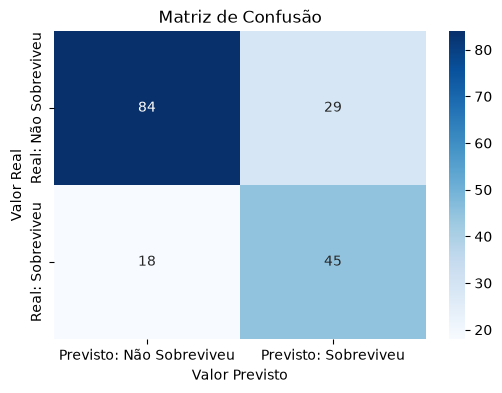


Métricas detalhadas:


,precision,recall,f1-score,support
0,0.823529,0.743363,0.781395,113.000000
1,0.608108,0.714286,0.656934,63.000000
accuracy,0.732955,0.732955,0.732955,0.732955
macro avg,0.715819,0.728824,0.719165,176.000000
weighted avg,0.746418,0.732955,0.736844,176.000000


In [65]:
#Analisando o resultado do modelo com matriz de confusão
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

#Fazendo previsões
y_pred = model.predict(X_test)

#Acurácia e relatório de classificação
acc = accuracy_score(y_test, y_pred)
report = classification_report(y_test, y_pred, output_dict=True)

#Exibir métricas principais
print(f"Acurácia: {acc:.2f}")
print("\nRelatório de Classificação:")
print(classification_report(y_test, y_pred))

#Matriz de confusão
cm = confusion_matrix(y_test, y_pred)

#Criando DataFrame para a matriz
cm_df = pd.DataFrame(cm,
                     index=["Real: Não Sobreviveu", "Real: Sobreviveu"],
                     columns=["Previsto: Não Sobreviveu", "Previsto: Sobreviveu"])

#Plotando
plt.figure(figsize=(6, 4))
sns.heatmap(cm_df, annot=True, fmt='d', cmap='Blues')
plt.title('Matriz de Confusão')
plt.ylabel('Valor Real')
plt.xlabel('Valor Previsto')
plt.show()

#Visualizando as métricas em formato tabular
report_df = pd.DataFrame(report).transpose()
print("\nMétricas detalhadas:")
display(report_df[['precision', 'recall', 'f1-score', 'support']])


# Conclusão

Este notebook analisou os dados dos passageiros do Titanic para prever a sobrevivência utilizando uma **Random Forest** com **OneHotEncoder** para tratamento das variáveis categóricas.

## O que a EDA revelou

A análise exploratória confirmou os fatores históricos mais conhecidos do desastre:

- **Gênero foi o maior determinante de sobrevivência** mulheres tiveram taxa de sobrevivência muito superior aos homens, reflexo da política "mulheres e crianças primeiro" adotada durante a evacuação
- **Classe social influenciou diretamente a sobrevivência** passageiros da 1ª classe tiveram acesso mais fácil aos botes salva-vidas, enquanto a 3ª classe teve a menor taxa de sobrevivência
- **A distribuição de idades dos sobreviventes e não sobreviventes é parecida**, sem uma faixa etária claramente mais favorecida embora crianças pequenas tenham tido prioridade na evacuação
- **Passageiros embarcados em Cherbourg (C) pagaram tarifas mais altas**, concentrando passageiros de 1ª classe o porto de Southampton (S) embarcou a maior parte dos passageiros

## Limpeza realizada
- **Colunas removidas:** `Cabin` (77% nulos), `PassengerId`, `Ticket`, `Name` e `SibSp` sem valor preditivo relevante
- **177 nulos em `Age`** preenchidos com a mediana (28 anos) e arredondados para inteiros
- **2 nulos em `Embarked`** preenchidos com a moda (Southampton)
- **15 passageiros com tarifa zero** removidos registros inconsistentes

## Resultado do Modelo

| Métrica | Não Sobreviveu (0) | Sobreviveu (1) |
|---------|-------------------|----------------|
| Precision | **0.82** | 0.61 |
| Recall | 0.74 | **0.71** |
| F1-score | 0.78 | 0.66 |
| **Acurácia geral** | | **73%** |

## Interpretação

O modelo atingiu **73% de acurácia** um resultado razoável para uma Random Forest simples nesse dataset. O modelo é mais preciso ao classificar quem **não sobreviveu** (Precision de 0.82) do que quem sobreviveu (0.61), o que é esperado dado que o dataset é levemente desbalanceado 535 não sobreviventes contra 341 sobreviventes.

O **Recall de 0.71 para sobreviventes** indica que o modelo identificou corretamente 71% dos que realmente sobreviveram perdendo 29%, que foram classificados incorretamente como não sobreviventes.

Como próximos passos, seria interessante realizar a otimização de hiperparâmetros (como n_estimators e max_depth), testar algoritmos de Gradient Boosting (como XGBoost ou LightGBM) ou reavaliar o impacto de manter a coluna SibSp ou criar novas features para melhorar o desempenho na classe dos sobreviventes.